In [1]:
import akshare as ak
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 重新拉取沪深300成分股收盘价
hs300 = ak.index_stock_cons_weight_csindex(symbol="000300")
stock_list = hs300["成分券代码"].tolist()

close_dict = {}
for i, code in enumerate(stock_list):
    try:
        df = ak.stock_zh_a_hist(symbol=code, adjust="qfq",
                                start_date="2023-01-01")
        close_dict[code] = df.set_index("日期")["收盘"]
        if i % 50 == 0:
            print(f"进度：{i}/300")
    except:
        continue

close_df = pd.DataFrame(close_dict)
close_df.index = pd.to_datetime(close_df.index)
close_df = close_df[close_df.index >= "2023-01-01"]
close_df = close_df.dropna(axis=1, thresh=len(close_df)*0.9)

print(f"\n数据加载完成：{close_df.shape}")

进度：0/300
进度：50/300
进度：100/300
进度：150/300
进度：200/300
进度：250/300

数据加载完成：(781, 296)


In [2]:
# 存成CSV，以后直接读本地
close_df.to_csv("close_data.csv")
print("已保存到 close_data.csv")

已保存到 close_data.csv


In [3]:
close_df = pd.read_csv("close_data.csv", index_col=0, parse_dates=True)

In [4]:
# 计算三个因子
momentum = close_df / close_df.shift(20) - 1
reversal = -(close_df / close_df.shift(5) - 1)

# 拉取换手率数据
volume_dict = {}
for i, code in enumerate(close_df.columns):
    try:
        df = ak.stock_zh_a_hist(symbol=code, adjust="qfq",
                                start_date="2023-01-01")
        volume_dict[code] = df.set_index("日期")["换手率"]
        if i % 50 == 0:
            print(f"进度：{i}/{len(close_df.columns)}")
    except:
        continue

volume_df = pd.DataFrame(volume_dict)
volume_df.index = pd.to_datetime(volume_df.index)
volume_df = volume_df[volume_df.index >= "2023-01-01"]
volume_df.to_csv("volume_data.csv")
print("换手率数据已保存")

进度：0/296
进度：50/296
进度：100/296
进度：150/296
进度：200/296
进度：250/296
换手率数据已保存


In [5]:
# 标准化函数
def standardize(factor):
    return (factor - factor.mean(axis=1).values.reshape(-1,1)) / \
            factor.std(axis=1).values.reshape(-1,1)

# 三因子标准化
mom_std = standardize(momentum)
rev_std = standardize(reversal)

volume_df2 = pd.read_csv("volume_data.csv", index_col=0, parse_dates=True)
turnover_factor = -volume_df2.rolling(20).mean()
turn_std = standardize(turnover_factor)

# 等权合成
combined = (mom_std + rev_std + turn_std) / 3

# 每月第一个交易日调仓，选因子排名前20%的股票
def get_selected_stocks(factor_row, top_pct=0.2):
    valid = factor_row.dropna()
    n = max(int(len(valid) * top_pct), 1)
    return valid.nlargest(n).index.tolist()

print("合成因子计算完成")
print(f"因子维度：{combined.shape}")

合成因子计算完成
因子维度：(781, 296)


In [7]:
# 回测参数
rebalance_freq = 20      # 每20个交易日调仓一次
top_pct = 0.2            # 选前20%的股票
cost = 0.002             # 每次交易成本0.2%

# 初始化
portfolio_value = [1.0]  # 初始净值为1
current_stocks = []      # 当前持仓

# 找到所有调仓日（每20个交易日）
dates = combined.index.tolist()
rebalance_dates = dates[20::rebalance_freq]

for i, date in enumerate(dates[20:], start=20):
    # 调仓日：重新选股
    if date in rebalance_dates:
        factor_row = combined.loc[date]
        current_stocks = get_selected_stocks(factor_row, top_pct)

    # 计算当天组合收益
    if len(current_stocks) == 0:
        portfolio_value.append(portfolio_value[-1])
        continue

    # 持仓股票当天的等权收益
    prev_date = dates[i-1]
    returns = []
    for code in current_stocks:
        if code in close_df.columns:
            try:
                r = close_df.loc[date, code] / close_df.loc[prev_date, code] - 1
                if not np.isnan(r):
                    returns.append(r)
            except:
                continue

    if len(returns) == 0:
        portfolio_value.append(portfolio_value[-1])
        continue

    daily_return = np.mean(returns)

    # 调仓日扣除交易成本
    if date in rebalance_dates:
        daily_return -= cost

    portfolio_value.append(portfolio_value[-1] * (1 + daily_return))

portfolio = pd.Series(portfolio_value, index=dates[20-1:])
print(f"回测完成，最终净值：{portfolio.iloc[-1]:.4f}")

回测完成，最终净值：1.0856


累计收益：8.56%
年化收益：2.75%
最大回撤：-22.73%
Sharpe Ratio：0.2423


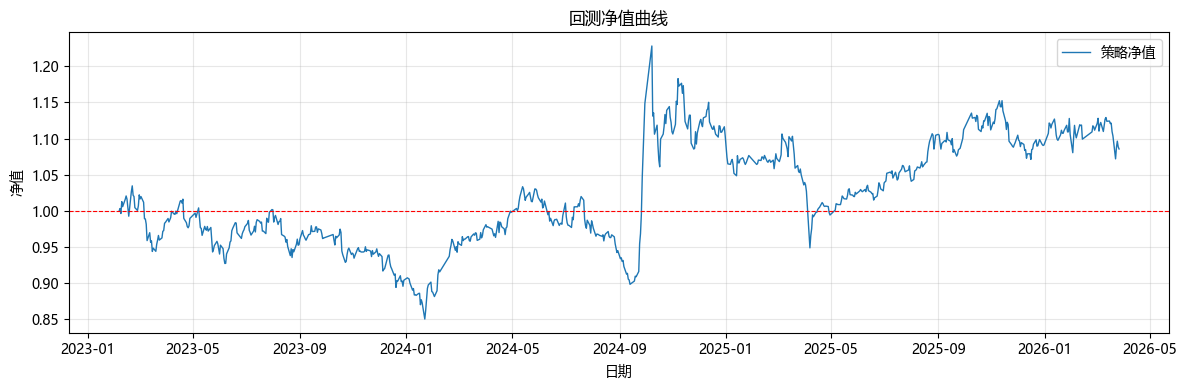

In [8]:
# 计算关键指标
total_return = portfolio.iloc[-1] - 1
days = len(portfolio)
annual_return = (1 + total_return) ** (252/days) - 1

# 最大回撤
rolling_max = portfolio.cummax()
drawdown = (portfolio - rolling_max) / rolling_max
max_drawdown = drawdown.min()

# Sharpe Ratio
daily_returns = portfolio.pct_change().dropna()
sharpe = daily_returns.mean() / daily_returns.std() * np.sqrt(252)

print(f"累计收益：{total_return:.2%}")
print(f"年化收益：{annual_return:.2%}")
print(f"最大回撤：{max_drawdown:.2%}")
print(f"Sharpe Ratio：{sharpe:.4f}")

# 画净值曲线
plt.figure(figsize=(12, 4))
plt.plot(portfolio.index, portfolio, linewidth=1, label="策略净值")
plt.axhline(y=1, color="red", linewidth=0.8, linestyle="--")
plt.title("回测净值曲线")
plt.xlabel("日期")
plt.ylabel("净值")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# 拉取沪深300指数数据
hs300_index = ak.stock_zh_index_daily(symbol="sh000300")
hs300_index["date"] = pd.to_datetime(hs300_index["date"])
hs300_index = hs300_index.set_index("date")
hs300_index = hs300_index[hs300_index.index >= portfolio.index[0]]

# 归一化到1，方便和策略净值对比
hs300_norm = hs300_index["close"] / hs300_index["close"].iloc[0]

print(f"沪深300数据：{hs300_norm.shape}")
print(hs300_norm.tail())

沪深300数据：(762,)
date
2026-03-23    1.081020
2026-03-24    1.094900
2026-03-25    1.110252
2026-03-26    1.095588
2026-03-27    1.101714
Name: close, dtype: float64


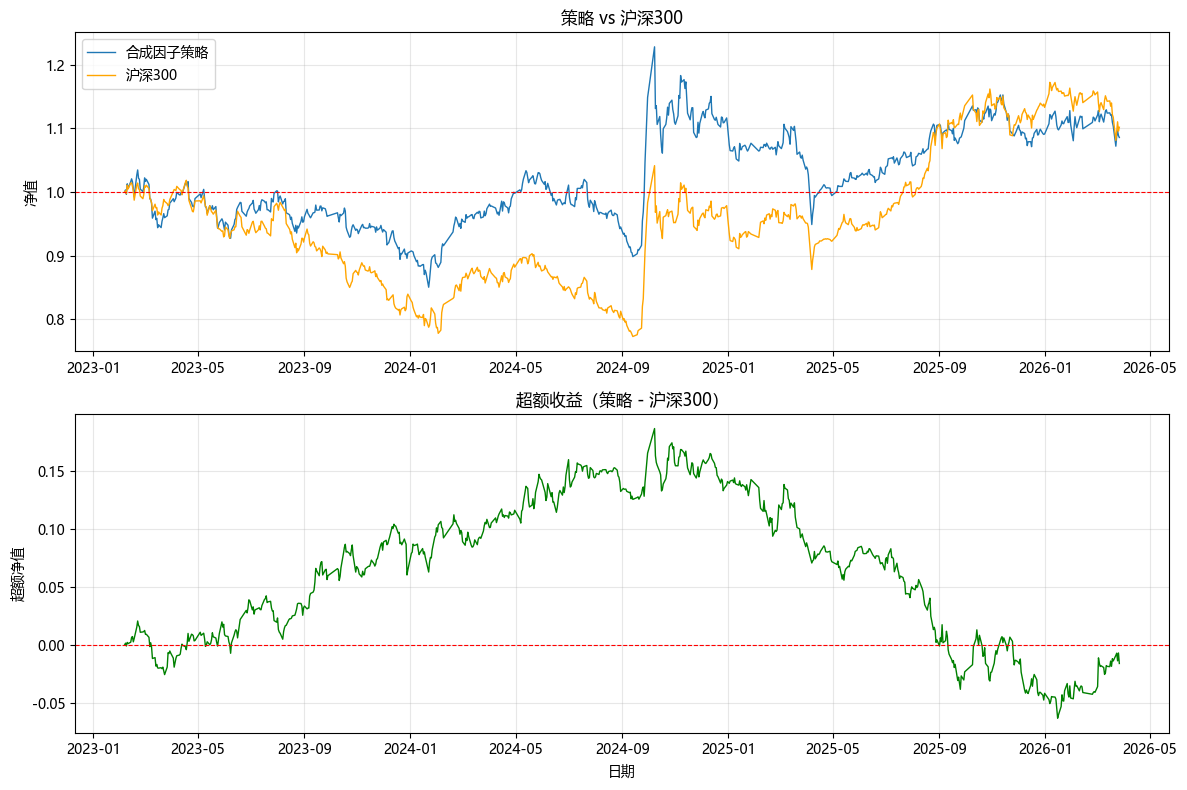

策略累计收益：8.56%
沪深300累计收益：10.17%
超额收益：-1.61%


In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# 上图：净值对比
ax1.plot(portfolio.index, portfolio, linewidth=1, label="合成因子策略")
ax1.plot(hs300_norm.index, hs300_norm, linewidth=1, label="沪深300", color="orange")
ax1.axhline(y=1, color="red", linewidth=0.8, linestyle="--")
ax1.set_title("策略 vs 沪深300")
ax1.set_ylabel("净值")
ax1.legend()
ax1.grid(True, alpha=0.3)

# 下图：超额收益（策略 - 沪深300）
# 对齐两个序列的日期
common_dates = portfolio.index.intersection(hs300_norm.index)
excess = portfolio[common_dates] - hs300_norm[common_dates]
ax2.plot(common_dates, excess, linewidth=1, color="green")
ax2.axhline(y=0, color="red", linewidth=0.8, linestyle="--")
ax2.set_title("超额收益（策略 - 沪深300）")
ax2.set_ylabel("超额净值")
ax2.set_xlabel("日期")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 打印对比指标
hs300_return = hs300_norm.iloc[-1] - 1
print(f"策略累计收益：{total_return:.2%}")
print(f"沪深300累计收益：{hs300_return:.2%}")
print(f"超额收益：{total_return - hs300_return:.2%}")